# EUbOPEN compounds Cell Painting → AnnData

Builds an AnnData object from the well-level CellProfiler profiles of the
[EUbOPEN compounds Cell Painting dataset](https://www.ebi.ac.uk/biostudies/studies/S-BIAD2262)
(BioImage Archive accession **S-BIAD2262**, [DOI 10.6019/S-BIAD2262](https://doi.org/10.6019/S-BIAD2262)):
U2OS cells imaged with the Cell Painting assay 48 h after treatment with chemical
probes and tool compounds from the [EUbOPEN](https://www.eubopen.org/) consortium.
One observation is a well, one variable is a CellProfiler feature.

This dataset lives only in the BioImage Archive — it has no Cell Painting Gallery
`cpg####` counterpart — and has no linked publication, so the deposit is the
primary record.

The archive holds, per 384-well plate, a `<plate>.zip` of raw images and a
`profiles/<plate>_profiles.parquet` of the assembled per-well profile. Only the
71 profile parquets are needed here; they and a small file manifest are fetched
from the BioStudies API and the BioImage Archive FTP mirror on first use.

In [1]:
from __future__ import annotations

import json
import time
from collections.abc import Iterable, Sequence
from pathlib import Path
from urllib.request import Request, urlopen

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

DATA_ROOT = Path("~/data/eubopen-cellpainting").expanduser()
SUBSET = "all"  # "all", or one campaign: "1d" (single dose), "1d2_dr1", "dr2" (dose-response)

ACCESSION = "S-BIAD2262"
BIOSTUDIES = f"https://www.ebi.ac.uk/biostudies/api/v1/studies/{ACCESSION}"
FTP = f"https://ftp.ebi.ac.uk/biostudies/fire/S-BIAD/{ACCESSION[6:9]}/{ACCESSION}/Files"

## Loading a subset

The 71 plates fall into three imaging campaigns, tagged in the file manifest by
`campaign_id`:

* `1d` — the main single-dose screen: 8 library plates, each imaged as 4
  replicates (`n1`, `n2`, `n5`, `n6`), every compound at 10 µM.
* `1d2_dr1` — a follow-up mixing single-dose (`1d`) and dose-response (`dr`)
  plates across four runs.
* `dr2` — a second dose-response campaign, one run.

Each parquet is already collapsed to one row per well: single cells were
segmented and measured with CellProfiler (the JUMP Cell Painting pipeline) and
reduced to a per-well profile, so the ~7,600 feature columns are still named
measurements. The 18 `meta_*` / `metadata_*` columns carry plate, well, compound,
and object counts.

These are **raw** profiles — the deposit states no normalization was applied — so
a subset only needs its variables intersected before stacking; the per-plate
normalization happens further down. Feature columns vary slightly between plates,
so `load_profiles` keeps their intersection.

In [2]:
CAMPAIGN = {
    "1d": "hcs_cellpainting_eubopen_1d",
    "1d2_dr1": "hcs_cellpainting_eubopen_1d2_dr1",
    "dr2": "hcs_cellpainting_eubopen_dr2",
}


def profile_manifest(root: Path) -> pd.DataFrame:
    """One row per profile parquet: plate barcode, batch, campaign, plate type."""
    cache = root / "file_manifest.json"
    if not cache.exists():
        root.mkdir(parents=True, exist_ok=True)
        with urlopen(f"{BIOSTUDIES}/files?limit=1000") as resp:  # EBI, https only
            cache.write_bytes(resp.read())
    items = json.loads(cache.read_text())["items"]
    return pd.DataFrame(
        [
            {"Plate": it["plate_id"], "Batch": it["batch_id"], "campaign_id": it["campaign_id"], "path": it["path"]}
            for it in items
            if it["path"].startswith("profiles/")
        ]
    )


def fetch_profile(path: str, root: Path, retries: int = 12) -> Path:
    """Fetch one profile parquet. The BioImage Archive FTP drops connections mid-transfer; retry the whole file."""
    dest = root / path
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and _readable_parquet(dest):
        return dest
    try:
        tmp = dest.with_suffix(dest.suffix + ".part")
        with urlopen(Request(f"{FTP}/{path}")) as resp, tmp.open("wb") as out:  # EBI, https only
            while chunk := resp.read(1 << 20):
                out.write(chunk)
        if not _readable_parquet(tmp):
            raise OSError("incomplete parquet")
        tmp.replace(dest)
    except Exception:  # transient FTP failure: drop the partial file and try again
        tmp.unlink(missing_ok=True)
        if retries <= 1:
            raise
        time.sleep(2)
        return fetch_profile(path, root, retries - 1)
    return dest


def _readable_parquet(path: Path) -> bool:
    try:
        pd.read_parquet(path, columns=["meta_id_plate"])
    except Exception:
        return False
    return True


def load_profiles(root: Path, subset: str) -> ad.AnnData:
    manifest = profile_manifest(root)
    if subset != "all":
        manifest = manifest[manifest["campaign_id"] == CAMPAIGN[subset]]
    if manifest.empty:
        raise ValueError(f"no plates for subset {subset!r}")

    frames = [pd.read_parquet(fetch_profile(p, root)) for p in manifest["path"]]
    meta_cols = [c for c in frames[0].columns if c.startswith(("meta_", "metadata_"))]
    feature_cols = sorted(set.intersection(*(set(f.columns) for f in frames)) - set(meta_cols))
    df = pd.concat((f[[*meta_cols, *feature_cols]] for f in frames), ignore_index=True)

    campaign_short = {v: k for k, v in CAMPAIGN.items()}
    control = df["meta_control_type"].fillna("")
    obs = pd.DataFrame(
        {
            "Campaign": df["meta_id_campaign"].map(campaign_short).to_numpy(),
            "Batch": df["meta_id_batch"].to_numpy(),
            "Replicate": df["meta_id_batch"].str.rsplit("_", n=1).str[-1].to_numpy(),
            "Plate": df["meta_id_plate"].to_numpy(),
            "PlateType": df["meta_plate_type"].to_numpy(),
            "Well": df["meta_id_well"].to_numpy(),
            "compound": df["meta_eubscarab_id"].fillna("").to_numpy(),
            "control_name": df["meta_control_id"].fillna("").to_numpy(),
            "concentration_uM": np.where(
                df["meta_concentration_unit"].eq("uM"), df["meta_concentration"], np.nan
            ).astype(np.float32),
            "cell_count": df["metadata_object_count"].to_numpy(),
            "pert_type": np.select([control.eq("negcon"), control.eq("poscon")], ["negcon", "poscon"], default="trt"),
        }
    )
    obs.index = pd.Index(obs["Batch"] + ":" + obs["Plate"] + ":" + obs["Well"], name="well")
    obs["pert_type"] = pd.Categorical(obs["pert_type"], categories=["negcon", "poscon", "trt"])
    var = pd.DataFrame(index=pd.Index(feature_cols, name="feature"))

    adata = ad.AnnData(X=df[feature_cols].to_numpy(np.float32), obs=obs, var=var)
    adata.uns["provenance"] = {
        "dataset": "EUbOPEN compounds Cell Painting",
        "accession": ACCESSION,
        "doi": "10.6019/S-BIAD2262",
        "url": f"https://www.ebi.ac.uk/biostudies/studies/{ACCESSION}",
        "subset": subset,
        "n_plates": int(manifest.shape[0]),
    }
    return adata


adata = load_profiles(DATA_ROOT, SUBSET)
adata

AnnData object with n_obs × n_vars = 20649 × 7648
    obs: 'Campaign', 'Batch', 'Replicate', 'Plate', 'PlateType', 'Well', 'compound', 'control_name', 'concentration_uM', 'cell_count', 'pert_type'
    uns: 'provenance'
    layers: None (.X)

## Well and compound annotation

Everything needed to describe a well is already in the parquet's `meta_*`
columns, so there is no join here — only a tidy-up and a categorical cast.
`meta_control_type` names the two controls: `negcon` is 0.1 % DMSO, `poscon` is a
cytotoxic / cytoskeletal reference compound named in `control_name` (e.g.
*Aloxistatine*). Every other well is a treatment, keyed by `compound` — the
EUbOPEN compound id from `meta_eubscarab_id`.

The deposit carries no compound → target / mechanism / structure table, so
`compound` stays as that opaque id; the EUbOPEN data portal resolves it to a
probe and its annotated target if that is needed later.

In [3]:
def categorize(adata: ad.AnnData, columns: Iterable[str]) -> None:
    for column in columns:
        adata.obs[column] = adata.obs[column].astype("category")


categorize(adata, ["Campaign", "Batch", "Replicate", "Plate", "PlateType", "Well", "compound", "control_name"])
adata.obs.head()

,Campaign,Batch,Replicate,Plate,PlateType,Well,compound,control_name,concentration_uM,cell_count,pert_type
well,,,,,,,,,,,
20241119_u2os_48h_1d_n1:AAATP24:A01,1d,20241119_u2os_48h_1d_n1,n1,AAATP24,1d,A01,,Aloxistatine,10.0,605,poscon
20241119_u2os_48h_1d_n1:AAATP24:A02,1d,20241119_u2os_48h_1d_n1,n1,AAATP24,1d,A02,,,NaN,663,negcon
20241119_u2os_48h_1d_n1:AAATP24:A03,1d,20241119_u2os_48h_1d_n1,n1,AAATP24,1d,A03,EUB0001947aCl,,10.0,641,trt
20241119_u2os_48h_1d_n1:AAATP24:A04,1d,20241119_u2os_48h_1d_n1,n1,AAATP24,1d,A04,EUB0001800a,,10.0,650,trt
20241119_u2os_48h_1d_n1:AAATP24:A23,1d,20241119_u2os_48h_1d_n1,n1,AAATP24,1d,A23,,,NaN,732,negcon


## Acquisition metadata

Microscope, objective, and channel configuration are properties of the imaging
campaign, not the well, so they go in `uns` as a small table rather than as
columns repeated tens of thousands of times. All 71 plates were imaged on one
instrument, so this is a single record, read from the study's `Image acquisition`
and `Image analysis` sections.

In [4]:
def add_acquisition_metadata(adata: ad.AnnData) -> None:
    cache = DATA_ROOT / "study.json"
    if not cache.exists():
        with urlopen(BIOSTUDIES) as resp:  # EBI, https only
            cache.write_bytes(resp.read())
    section = json.loads(cache.read_text())["section"]

    def walk(node: object) -> Iterable[dict]:
        if isinstance(node, dict):
            if node.get("type"):
                yield node
            for value in node.values():
                yield from walk(value)
        elif isinstance(node, list):
            for item in node:
                yield from walk(item)

    wanted = {"Image acquisition", "Image analysis", "Specimen"}
    acquisition = {
        attr["name"]: attr["value"]
        for sub in walk(section)
        if sub.get("type") in wanted
        for attr in sub.get("attributes", [])
        if attr.get("name") != "Title"
    }
    adata.uns["acquisition"] = acquisition


add_acquisition_metadata(adata)
adata.uns["acquisition"]

{'Sample preparation protocol': 'Refer to cell painting publication for details : \nhttps://www.nature.com/articles/s41596-023-00840-9',
 'Imaging instrument': 'Yokogawa CV8000',
 'Image acquisition parameters': '20x air objective\n\nChannels:\nExcitation : 405nm / Excitation Power : 100% / Emission filter : 445/45 / Z offset : -7.5um\nExcitation : 488nm / Excitation Power : 100% / Emission filter : 525/50 / Z offset : -7.5um\nExcitation : 488nm / Excitation Power : 100% / Emission filter : 600/37 / Z offset : -7.5um\nExcitation : 561nm / Excitation Power : 100% / Emission filter : 600/37 / Z offset : -7.5um\nExcitation : 640nm / Excitation Power : 100% / Emission filter : 676/29 / Z offset : -7.5um\nExcitation : BrightField LED (confocal path) / Excitation Power : 30% / Emission filter : 525/50 /\nZ offset : -7.5um',
 'Imaging method': 'confocal microscopy',
 'Image analysis overview': 'Per well profiles have been computed using CellProfiler.\nThe protocol used to configure CellProfil

## Feature annotation

`adata.var` is derived from the feature names alone and can be dropped without
touching the matrix. These names are lower-cased CellProfiler columns following
`<compartment>_<family>_<measurement>[_<channel>][_<parameters>]`, with
compartment one of `cells` / `cytoplasm` / `nuclei` / `image` (whole-field
measurements).

This is a full, non-selected profile: every texture scale and angle, every
granularity scale, and every radial bin is a separate column, which is why there
are ~7,600 of them. The stain is the five-channel Cell Painting set — `DNA`,
`RNA`, `ER`, `AGP`, `Mito` — plus three brightfield planes (`Brightfield`,
`BFHigh`, `BFLow`) that this pipeline also measured. `correlation` features name
a channel *pair*; `areashape`, `neighbors`, and the mitochondrial-skeleton
(`objectskeleton`) features have no channel.

In [5]:
CHANNELS: Sequence[str] = ("DNA", "RNA", "ER", "AGP", "Mito", "Brightfield", "BFHigh", "BFLow")
COMPARTMENTS = {"cells": "Cells", "cytoplasm": "Cytoplasm", "nuclei": "Nuclei", "image": "Image"}


def annotate_features(var: pd.DataFrame, channels: Sequence[str] = CHANNELS) -> None:
    tokens = [name.split("_") for name in var.index]
    lookup = {c.lower(): c for c in channels}
    matched = [[lookup[t] for t in token if t in lookup] for token in tokens]
    var["compartment"] = pd.Categorical([COMPARTMENTS.get(t[0], t[0]) for t in tokens])
    var["family"] = pd.Categorical([t[1] if len(t) > 1 else "" for t in tokens])
    var["channel"] = pd.Categorical([c[0] if c else None for c in matched])
    var["channel_2"] = pd.Categorical([c[1] if len(c) > 1 else None for c in matched])
    var["n_channels"] = np.array([len(c) for c in matched], dtype=np.int8)


annotate_features(adata.var)
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
cells_areashape_area,Cells,areashape,NaN,NaN,0
cells_areashape_boundingboxarea,Cells,areashape,NaN,NaN,0
cells_areashape_boundingboxmaximum_x,Cells,areashape,NaN,NaN,0
cells_areashape_boundingboxmaximum_y,Cells,areashape,NaN,NaN,0
cells_areashape_boundingboxminimum_x,Cells,areashape,NaN,NaN,0
...,...,...,...,...,...
nuclei_texture_variance_rna_3_03_256,Nuclei,texture,RNA,NaN,1
nuclei_texture_variance_rna_5_00_256,Nuclei,texture,RNA,NaN,1
nuclei_texture_variance_rna_5_01_256,Nuclei,texture,RNA,NaN,1


`areashape` bounding-box corners and object centroids (`location`,
`center_x/y`), and the `number` / `parent` / `children` object-tracking columns,
encode a cell's position in its field of view or its lineage, not its phenotype.
Drop them.

In [6]:
_BOOKKEEPING = ("boundingbox", "center_x", "center_y", "location", "objectnumber")
keep = [
    fam not in ("number", "parent", "children") and not any(tok in name for tok in _BOOKKEEPING)
    for name, fam in zip(adata.var_names, adata.var["family"], strict=True)
]
adata = adata[:, keep].copy()

## Normalization

Each plate is normalized on its own, against its DMSO wells: subtract the DMSO
median and divide by the DMSO MAD (scaled to a standard deviation), feature by
feature — `pycytominer`'s `mad_robustize`. The result is a robust z-score against
the plate's negative controls. The raw per-well profiles are kept in
`adata.layers["aggregated"]`.

A feature that is constant across some plate's DMSO wells has zero MAD there and
goes to NaN on that plate; rather than impute, any feature left non-finite on
even one plate is dropped from the whole object.

In [7]:
def mad_robustize(adata: ad.AnnData, group_keys: Sequence[str], control_mask: np.ndarray) -> None:
    adata.layers["aggregated"] = adata.X.copy()
    X = adata.X.astype(np.float64)
    out = np.full_like(X, np.nan)
    groups = adata.obs.groupby(list(group_keys), observed=True).indices
    for idx in groups.values():
        ref = X[np.intersect1d(idx, np.flatnonzero(control_mask))]
        median = np.median(ref, axis=0)
        mad = np.median(np.abs(ref - median), axis=0) * 1.4826
        scale = np.where(mad == 0, np.nan, mad)
        out[idx] = (X[idx] - median) / scale
    adata.X = out.astype(np.float32)


mad_robustize(adata, ("Plate",), adata.obs["pert_type"].eq("negcon").to_numpy())

finite_cols = np.isfinite(adata.X).all(axis=0)
print(f"dropping {int((~finite_cols).sum())} features with zero MAD on some plate")
adata = adata[:, finite_cols].copy()

dropping 192 features with zero MAD on some plate


## Sanity checks

Well counts fall short of 384 per plate wherever segmentation failed outright
(dead or empty wells); those rows are simply absent from the parquet. The `1d`
campaign also includes several deliberately small library plates.

In [8]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"campaigns: {sorted(adata.obs['Campaign'].unique())}")
print(f"replicates: {sorted(adata.obs['Replicate'].unique())}")
print(f"wells per plate: min {adata.obs['Plate'].value_counts().min()}, max {adata.obs['Plate'].value_counts().max()}")
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(f"unique compounds: {adata.obs['compound'].nunique() - 1:,} (excl. the empty control label)")
print(adata.obs["pert_type"].value_counts())

20,649 wells x 7,372 features across 71 plates
campaigns: ['1d', '1d2_dr1', 'dr2']
replicates: ['n1', 'n2', 'n5', 'n6', 'run1', 'run2', 'run3', 'run4']
wells per plate: min 68, max 384
non-finite values: 0
unique compounds: 1,642 (excl. the empty control label)
pert_type
trt       16098
negcon     2276
poscon     2275
Name: count, dtype: int64


In [9]:
adata.write_h5ad(DATA_ROOT / f"eubopen_{SUBSET}.h5ad")

## UMAP

The profiles are already per-plate robust z-scores, so they enter PCA unscaled.

In [10]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/Users/luisheinzlmeier/Desktop/cellpainting/WS1/cell-painting-io/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A UMAP of these profiles is easy to over-read, so measure the structure before
looking at it. How often do neighbouring wells share a label, against the rate
expected if labels were shuffled?

In [11]:
def neighbour_enrichment(adata: ad.AnnData, keys: Iterable[str]) -> pd.DataFrame:
    graph = adata.obsp["connectivities"].tocoo()
    rows = []
    for key in keys:
        labels = adata.obs[key].to_numpy()
        observed = float((labels[graph.row] == labels[graph.col]).mean())
        baseline = float((adata.obs[key].value_counts(normalize=True).to_numpy() ** 2).sum())
        rows.append({"covariate": key, "observed": observed, "baseline": baseline, "ratio": observed / baseline})
    return pd.DataFrame(rows).set_index("covariate").round(3)


neighbour_enrichment(adata, ["Plate", "Campaign", "pert_type", "compound"])

,observed,baseline,ratio
covariate,,,
Plate,0.111,0.017,6.642
Campaign,0.560,0.389,1.440
pert_type,0.767,0.632,1.214
compound,0.132,0.049,2.674


Plate is by far the strongest structure by ratio (~6.6x over chance): even after
per-plate normalization, plate-level batch effects survive — unsurprising when the
71 plates span three campaigns and roughly five months of imaging. Same-compound
wells come next (~2.7x), well below the ~14x the EU-OS bioactives notebook sees,
because most compounds here are screened once or twice rather than in four tight
replicates, and a single 10 µM dose leaves many probes with too small a phenotype
to localize. `Campaign` and `pert_type` sit only just above their (already high)
baselines.

In absolute terms neighbouring wells share a specific compound only ~13% of the
time. As with the JUMP and EU-OS profile sets, this is why compounds are scored by
replicate reproducibility against matched controls rather than by clustering the
profiles directly.

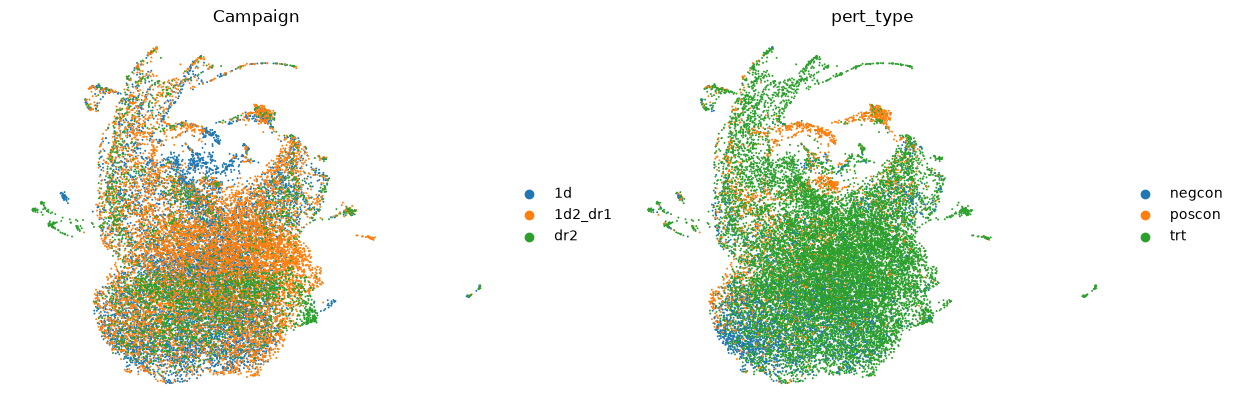

In [12]:
sc.pl.umap(adata, color=["Campaign", "pert_type"], ncols=2, frameon=False, size=8)